# Quantum Optimization for Distributed Order Management (DOM)

## Notebook 01 – Data Understanding

### WISER Global Quantum + AI Summer Program 2026

**Organization:** Nestlé

---

## Objective

This notebook explores the datasets provided for the WISER–Nestlé Distributed Order Management (DOM) challenge.

The goal is to understand the structure, quality, and business meaning of the data before performing exploratory analysis and optimization. A good understanding of the data is essential for building reliable classical and quantum optimization models.

In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data"

print("Data folder:", DATA_PATH)

Data folder: ../data


## Project Data Directory

All datasets used in this project are stored inside the `data` folder.

This notebook accesses these datasets to understand the available information before preprocessing and optimization.

## Available Challenge Files

Before loading the datasets, we inspect the project directory to verify that all required files are available.

This helps ensure that the project structure is correct and that no required dataset is missing.

In [4]:
for root, dirs, files in os.walk(DATA_PATH):
    print(f"\nFolder: {root}")
    for file in files:
        print("   ", file)


Folder: ../data
    .DS_Store
    DOM Equations.docx
    Example.xlsx
    output_order_sku_level_data.csv

Folder: ../data\input data
    input_capacity_planning.csv
    input_dock_capacity.csv
    input_order_data.csv
    input_shipping_cost_data.csv
    input_throughput_capacity.csv


### Observation

The required project files are successfully detected.

The available datasets include order information, shipping costs, warehouse capacities, and optimization outputs that will be used throughout the project.

## Load Order Dataset

The Order dataset represents customer demand.

Each row corresponds to an order containing product information, requested quantity, and the default Distribution Center (DC) responsible for fulfillment.

In [5]:
orders = pd.read_csv("../data/input data/input_order_data.csv")

orders.head()

,Group_Flag,Plant,MaterialNumber,transportationplanningdate,CustomerGroup5Description,IsTopCust,OpeningStock,RequestedDeliveryDate,DeliveryNoteFlag,IsInvAvail,LoadNumber,DeliveryPriority,ProductPlanningUnitOfMeasure,ProductPlanningUnitsPerCase,ProductPlanningUnitsPerPallet,OrderedQty_converted,OrderedWeight,OrderedVolume,Order_SKU_Revenue,ZipCode,ProductCasesPerPallet,CalculatedFootprints,IsCOF<100,calculated_ordered_weight,IsFTL,IsMultiplePlant,IsMultiplePGI,IsMultipleRDD,Measure,FillRateThreshold,Penaltyforpotentialcuts,MaximumPenalty,FixedPenalty,FixedPenaltyPerSKU,MinimumPenalty,Additionalcomments,OnTimePercentage,OnTimeFixed,Unnamed: 38
0,5484913123,5083,12260382,6/26/24,NaN,N,33814.0,6/27/24,N,Y,U600105191,99,CS,1.0,120.0,24,386.435,10.032,1150,431,120.0,7,Y,39463.21,Y,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5484913123,5083,9516458,6/26/24,NaN,N,6546.0,6/27/24,N,Y,U600105191,99,CS,1.0,80.0,10,90.078,7.360,478,431,80.0,7,Y,39463.21,Y,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5484913123,5083,12408924,6/26/24,NaN,N,4151.0,6/27/24,N,Y,U600105191,99,CS,1.0,128.0,4,64.774,1.352,832,431,128.0,7,Y,39463.21,Y,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5484913123,5083,9517630,6/26/24,NaN,N,17667.0,6/27/24,N,Y,U600105191,99,CS,1.0,160.0,114,250.888,28.728,7364,431,160.0,7,Y,39463.21,Y,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5484913123,5083,12587091,6/26/24,NaN,N,89341.0,6/27/24,N,Y,U600105191,99,CS,1.0,128.0,59,912.541,20.237,1756,431,128.0,7,Y,39463.21,Y,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation

The first few records confirm that the dataset has been loaded successfully.

Each record represents a customer order that will later be evaluated for reassignment during the optimization process.

## Dataset Structure

The dataset structure is inspected to understand the number of records, available features, data types, and potential missing values.

This information is important before any preprocessing or optimization.

In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 25193 entries, 0 to 25192
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Group_Flag                     25193 non-null  int64  
 1   Plant                          25193 non-null  int64  
 2   MaterialNumber                 25193 non-null  int64  
 3   transportationplanningdate     25193 non-null  str    
 4   CustomerGroup5Description      0 non-null      float64
 5   IsTopCust                      25193 non-null  str    
 6   OpeningStock                   25179 non-null  float64
 7   RequestedDeliveryDate          25193 non-null  str    
 8   DeliveryNoteFlag               25193 non-null  str    
 9   IsInvAvail                     25193 non-null  str    
 10  LoadNumber                     24279 non-null  str    
 11  DeliveryPriority               25193 non-null  int64  
 12  ProductPlanningUnitOfMeasure   25193 non-null  str    
 1

### Observation

The dataset structure shows the available attributes and their corresponding data types.

Most variables are already in a suitable format for further analysis.

## Descriptive Statistics

Descriptive statistics provide an overview of the distribution of numerical and categorical variables.

These statistics help identify unusual values and understand the characteristics of the order data.

In [8]:
orders.describe(include="all")

,Group_Flag,Plant,MaterialNumber,transportationplanningdate,CustomerGroup5Description,IsTopCust,OpeningStock,RequestedDeliveryDate,DeliveryNoteFlag,IsInvAvail,LoadNumber,DeliveryPriority,ProductPlanningUnitOfMeasure,ProductPlanningUnitsPerCase,ProductPlanningUnitsPerPallet,OrderedQty_converted,OrderedWeight,OrderedVolume,Order_SKU_Revenue,ZipCode,ProductCasesPerPallet,CalculatedFootprints,IsCOF<100,calculated_ordered_weight,IsFTL,IsMultiplePlant,IsMultiplePGI,IsMultipleRDD,Measure,FillRateThreshold,Penaltyforpotentialcuts,MaximumPenalty,FixedPenalty,FixedPenaltyPerSKU,MinimumPenalty,Additionalcomments,OnTimePercentage,OnTimeFixed,Unnamed: 38
count,2.519300e+04,25193.000000,2.519300e+04,25193,0.0,25193,25179.000000,25193,25193,25193,24279,25193.000000,25193,25130.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193,25193.000000,25193,25193,25193,25193,19987,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000,0.0,19987.000000,19987.000000,0.0
unique,NaN,NaN,NaN,10,NaN,2,NaN,12,1,2,614,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,1,1,1,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,6/26/24,NaN,Y,NaN,6/27/24,N,Y,U108970516,NaN,CS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,Y,N,N,N,PO's,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,8212,NaN,19987,NaN,7514,25193,23602,243,NaN,24820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20869,NaN,25193,25193,25193,25193,10047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.065104e+09,5427.501846,1.211594e+07,NaN,NaN,NaN,11699.775646,NaN,NaN,NaN,NaN,98.949430,NaN,0.987997,155.860755,93.105744,962.544656,39.206584,3512.557496,511.587981,157.421665,4.880562,NaN,40226.605207,NaN,NaN,NaN,NaN,NaN,0.817034,0.023696,264.672037,34.497423,0.490319,2.961925,NaN,0.021090,37.049082,NaN
std,1.067295e+09,141.190486,8.990101e+05,NaN,NaN,NaN,22928.261269,NaN,NaN,NaN,NaN,2.144635,NaN,0.107417,103.365373,205.471873,2530.415834,106.455177,10390.032432,284.639435,102.665261,5.154372,NaN,6878.548949,NaN,NaN,NaN,NaN,NaN,0.347875,0.014900,1119.540802,126.725857,13.091207,16.953876,NaN,0.013708,132.641239,NaN
min,5.478570e+09,5083.000000,6.211691e+06,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,8.000000,NaN,0.002778,1.000000,1.000000,0.000000,0.073000,8.000000,15.000000,1.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,5.485358e+09,5385.000000,1.222887e+07,NaN,NaN,NaN,1407.500000,NaN,NaN,NaN,NaN,99.000000,NaN,1.000000,96.000000,20.000000,122.692000,6.138000,542.000000,286.000000,96.000000,1.000000,NaN,39949.943000,NaN,NaN,NaN,NaN,NaN,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
50%,5.485499e+09,5410.000000,1.240779e+07,NaN,NaN,NaN,4711.000000,NaN,NaN,NaN,NaN,99.000000,NaN,1.000000,128.000000,46.000000,337.571000,17.025000,1492.000000,481.000000,128.000000,3.000000,NaN,43267.085000,NaN,NaN,NaN,NaN,NaN,0.975000,0.030000,0.000000,0.000000,0.000000,0.000000,NaN,0.030000,0.000000,NaN
75%,5.485629e+09,5490.000000,1.246878e+07,NaN,NaN,NaN,12129.000000,NaN,NaN,NaN,NaN,99.000000,NaN,1.000000,210.000000,109.000000,955.924000,43.540000,3678.000000,781.000000,216.000000,7.000000,NaN,44292.257000,NaN,NaN,NaN,NaN,NaN,0.980000,0.030000,0.000000,0.000000,0.000000,0.000000,NaN,0.030000,0.000000,NaN


### Observation

The statistical summary provides useful information about the range, frequency, and distribution of order-related attributes.

These insights support future optimization decisions.

## Dataset Dimensions

The number of rows and columns provides a quick overview of the dataset size.

Understanding dataset dimensions is useful when estimating computational complexity for optimization algorithms.

In [6]:
print("Number of Rows :", orders.shape[0])
print("Number of Columns :", orders.shape[1])

Number of Rows : 25193
Number of Columns : 39


## Feature Names

This section lists all available attributes contained in the order dataset.

Understanding each feature helps determine which variables are relevant for optimization.

In [10]:
print(orders.columns.tolist())

['Group_Flag', 'Plant', 'MaterialNumber', 'transportationplanningdate', 'CustomerGroup5Description', 'IsTopCust', 'OpeningStock', 'RequestedDeliveryDate', 'DeliveryNoteFlag', 'IsInvAvail', 'LoadNumber', 'DeliveryPriority', 'ProductPlanningUnitOfMeasure', 'ProductPlanningUnitsPerCase', 'ProductPlanningUnitsPerPallet', 'OrderedQty_converted', 'OrderedWeight', 'OrderedVolume', 'Order_SKU_Revenue', 'ZipCode', 'ProductCasesPerPallet', 'CalculatedFootprints', 'IsCOF<100', 'calculated_ordered_weight', 'IsFTL', 'IsMultiplePlant', 'IsMultiplePGI', 'IsMultipleRDD', 'Measure', 'FillRateThreshold', 'Penaltyforpotentialcuts', 'MaximumPenalty', 'FixedPenalty', 'FixedPenaltyPerSKU', 'MinimumPenalty', 'Additionalcomments', 'OnTimePercentage', 'OnTimeFixed', 'Unnamed: 38']


## Missing Value Analysis

Before building optimization models, we verify whether the dataset contains missing values.

Missing values may affect optimization quality and require preprocessing.

In [12]:
missing = orders.isnull().sum().sort_values(ascending=False)

print(missing)

CustomerGroup5Description        25193
Additionalcomments               25193
Unnamed: 38                      25193
Measure                           5206
MinimumPenalty                    5206
OnTimeFixed                       5206
Penaltyforpotentialcuts           5206
FixedPenaltyPerSKU                5206
FillRateThreshold                 5206
OnTimePercentage                  5206
FixedPenalty                      5206
MaximumPenalty                    5206
LoadNumber                         914
ProductPlanningUnitsPerCase         63
OpeningStock                        14
IsTopCust                            0
transportationplanningdate           0
Plant                                0
MaterialNumber                       0
Group_Flag                           0
IsInvAvail                           0
DeliveryNoteFlag                     0
RequestedDeliveryDate                0
IsCOF<100                            0
CalculatedFootprints                 0
ProductCasesPerPallet    

### Observation

The missing value summary helps identify incomplete attributes.

Columns with high missing percentages would require cleaning before optimization.

## Missing Value Percentage

In addition to the number of missing values, we calculate their percentage.

This helps determine whether a feature should be retained or removed.

In [13]:
missing_percent = (orders.isnull().sum()/len(orders))*100

missing_percent.sort_values(ascending=False)

CustomerGroup5Description        100.000000
Additionalcomments               100.000000
Unnamed: 38                      100.000000
Measure                           20.664470
MinimumPenalty                    20.664470
OnTimeFixed                       20.664470
Penaltyforpotentialcuts           20.664470
FixedPenaltyPerSKU                20.664470
FillRateThreshold                 20.664470
OnTimePercentage                  20.664470
FixedPenalty                      20.664470
MaximumPenalty                    20.664470
LoadNumber                         3.627992
ProductPlanningUnitsPerCase        0.250069
OpeningStock                       0.055571
IsTopCust                          0.000000
transportationplanningdate         0.000000
Plant                              0.000000
MaterialNumber                     0.000000
Group_Flag                         0.000000
IsInvAvail                         0.000000
DeliveryNoteFlag                   0.000000
RequestedDeliveryDate           

## Duplicate Record Analysis

Duplicate customer orders may lead to incorrect optimization decisions.

This section checks whether duplicate records exist.

In [14]:
print("Duplicate Rows:", orders.duplicated().sum())

Duplicate Rows: 0


### Observation

The duplicate analysis confirms whether each order is uniquely represented in the dataset.

## Data Type Inspection

This section verifies the data type of each feature.

Correct data types are important for preprocessing and optimization.

In [15]:
orders.dtypes

Group_Flag                         int64
Plant                              int64
MaterialNumber                     int64
transportationplanningdate           str
CustomerGroup5Description        float64
IsTopCust                            str
OpeningStock                     float64
RequestedDeliveryDate                str
DeliveryNoteFlag                     str
IsInvAvail                           str
LoadNumber                           str
DeliveryPriority                   int64
ProductPlanningUnitOfMeasure         str
ProductPlanningUnitsPerCase      float64
ProductPlanningUnitsPerPallet    float64
OrderedQty_converted               int64
OrderedWeight                    float64
OrderedVolume                    float64
Order_SKU_Revenue                  int64
ZipCode                            int64
ProductCasesPerPallet            float64
CalculatedFootprints               int64
IsCOF<100                            str
calculated_ordered_weight        float64
IsFTL           

## Unique Value Analysis

The number of unique values provides insight into categorical variables and identifier columns.

This information is useful for encoding and feature engineering.

In [16]:
orders.nunique()

Group_Flag                        1109
Plant                                8
MaterialNumber                    1110
transportationplanningdate          10
CustomerGroup5Description            0
IsTopCust                            2
OpeningStock                      8300
RequestedDeliveryDate               12
DeliveryNoteFlag                     1
IsInvAvail                           2
LoadNumber                         614
DeliveryPriority                     2
ProductPlanningUnitOfMeasure         2
ProductPlanningUnitsPerCase         18
ProductPlanningUnitsPerPallet      107
OrderedQty_converted               525
OrderedWeight                    17629
OrderedVolume                     5864
Order_SKU_Revenue                 5389
ZipCode                            211
ProductCasesPerPallet              112
CalculatedFootprints                37
IsCOF<100                            2
calculated_ordered_weight          604
IsFTL                                1
IsMultiplePlant          

## Data Cleaning

Basic preprocessing is performed to prepare the dataset for further analysis.

The cleaning process includes creating a cleaned copy of the original dataset and removing unnecessary or empty columns.

This ensures that the optimization models operate on clean and consistent data.

In [17]:
orders_clean = orders.copy()

print("Copy Created Successfully")

Copy Created Successfully


In [18]:
orders_clean = orders_clean.dropna(axis=1, how="all")

print("New Shape:", orders_clean.shape)

New Shape: (25193, 36)


In [19]:
orders_clean.describe()

,Group_Flag,Plant,MaterialNumber,OpeningStock,DeliveryPriority,ProductPlanningUnitsPerCase,ProductPlanningUnitsPerPallet,OrderedQty_converted,OrderedWeight,OrderedVolume,Order_SKU_Revenue,ZipCode,ProductCasesPerPallet,CalculatedFootprints,calculated_ordered_weight,FillRateThreshold,Penaltyforpotentialcuts,MaximumPenalty,FixedPenalty,FixedPenaltyPerSKU,MinimumPenalty,OnTimePercentage,OnTimeFixed
count,2.519300e+04,25193.000000,2.519300e+04,25179.000000,25193.000000,25130.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,25193.000000,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000,19987.000000
mean,6.065104e+09,5427.501846,1.211594e+07,11699.775646,98.949430,0.987997,155.860755,93.105744,962.544656,39.206584,3512.557496,511.587981,157.421665,4.880562,40226.605207,0.817034,0.023696,264.672037,34.497423,0.490319,2.961925,0.021090,37.049082
std,1.067295e+09,141.190486,8.990101e+05,22928.261269,2.144635,0.107417,103.365373,205.471873,2530.415834,106.455177,10390.032432,284.639435,102.665261,5.154372,6878.548949,0.347875,0.014900,1119.540802,126.725857,13.091207,16.953876,0.013708,132.641239
min,5.478570e+09,5083.000000,6.211691e+06,0.000000,8.000000,0.002778,1.000000,1.000000,0.000000,0.073000,8.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.485358e+09,5385.000000,1.222887e+07,1407.500000,99.000000,1.000000,96.000000,20.000000,122.692000,6.138000,542.000000,286.000000,96.000000,1.000000,39949.943000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.485499e+09,5410.000000,1.240779e+07,4711.000000,99.000000,1.000000,128.000000,46.000000,337.571000,17.025000,1492.000000,481.000000,128.000000,3.000000,43267.085000,0.975000,0.030000,0.000000,0.000000,0.000000,0.000000,0.030000,0.000000
75%,5.485629e+09,5490.000000,1.246878e+07,12129.000000,99.000000,1.000000,210.000000,109.000000,955.924000,43.540000,3678.000000,781.000000,216.000000,7.000000,44292.257000,0.980000,0.030000,0.000000,0.000000,0.000000,0.000000,0.030000,0.000000
max,8.029891e+09,5773.000000,2.202030e+07,352760.000000,99.000000,1.000000,680.000000,7850.000000,44966.142000,2983.680000,356600.000000,989.000000,680.000000,59.000000,48068.042000,1.000000,0.040000,5000.000000,500.000000,350.000000,100.000000,0.030000,750.000000


In [20]:
orders_clean.describe(include="object")

C:\Users\Bushra Faizi\AppData\Local\Temp\ipykernel_18572\59388661.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  orders_clean.describe(include="object")


,transportationplanningdate,IsTopCust,RequestedDeliveryDate,DeliveryNoteFlag,IsInvAvail,LoadNumber,ProductPlanningUnitOfMeasure,IsCOF<100,IsFTL,IsMultiplePlant,IsMultiplePGI,IsMultipleRDD,Measure
count,25193,25193,25193,25193,25193,24279,25193,25193,25193,25193,25193,25193,19987
unique,10,2,12,1,2,614,2,2,1,1,1,1,3
top,6/26/24,Y,6/27/24,N,Y,U108970516,CS,Y,Y,N,N,N,PO's
freq,8212,19987,7514,25193,23602,243,24820,20869,25193,25193,25193,25193,10047


## Distribution of Order Quantities

This visualization illustrates the distribution of customer order quantities.

Understanding demand distribution helps identify common order sizes, unusual requests, and potential outliers that may influence optimization decisions.

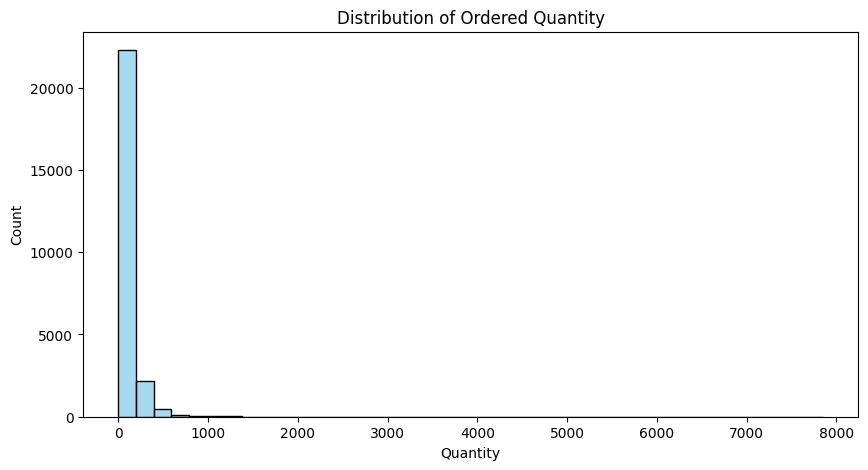

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders_clean["OrderedQty_converted"],
    bins=40,
    color="skyblue"
)

plt.title("Distribution of Ordered Quantity")
plt.xlabel("Quantity")
plt.ylabel("Count")

plt.show()

### Observation

The histogram shows how frequently different order quantities occur.

Most customer orders are concentrated within a particular range, while very large orders appear less frequently. These patterns are useful when designing optimization strategies.

## Sales Revenue Analysis

This visualization shows the distribution of revenue generated by customer orders.

Revenue is an important business metric because high-value orders may receive higher priority during optimization.

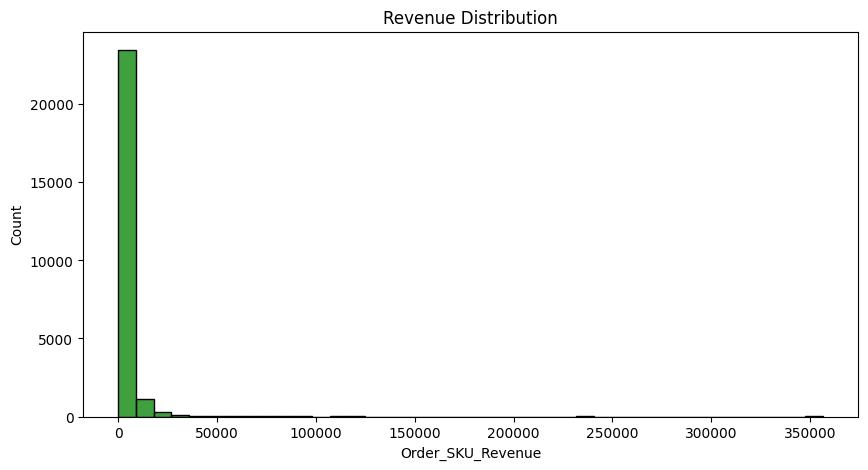

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders_clean["Order_SKU_Revenue"],
    bins=40,
    color="green"
)

plt.title("Revenue Distribution")

plt.show()

### Observation

The revenue distribution highlights the variation in order values.

Understanding this distribution helps evaluate the business impact of fulfillment decisions.

## Distribution Center (Plant) Analysis

This chart shows how customer orders are distributed across different Distribution Centers (Plants).

It helps identify workload distribution and heavily utilized fulfillment locations.

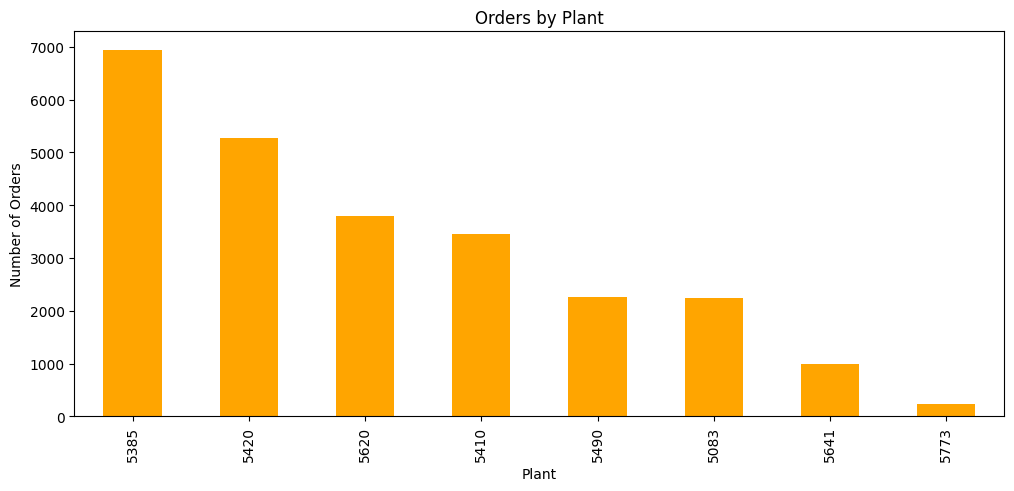

In [23]:
plt.figure(figsize=(12,5))

orders_clean["Plant"].value_counts().plot(
    kind="bar",
    color="orange"
)

plt.title("Orders by Plant")
plt.xlabel("Plant")
plt.ylabel("Number of Orders")

plt.show()

### Observation

Some Distribution Centers process considerably more orders than others.

These workload differences are important because capacity constraints play a major role in the optimization model.

## Inventory Availability Analysis

This visualization shows whether inventory is available for customer orders.

Inventory availability directly affects whether an order can be fulfilled from its default Distribution Center or needs reassignment.

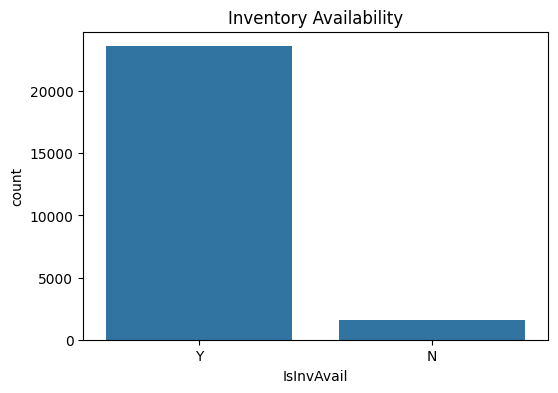

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=orders_clean,
    x="IsInvAvail"
)

plt.title("Inventory Availability")

plt.show()

### Observation

The chart compares orders with available inventory against those without inventory.

Inventory shortages increase the likelihood that optimization will recommend assigning orders to alternative Distribution Centers.

## Delivery Priority Analysis

Customer orders are grouped according to their delivery priority.

High-priority orders generally require faster fulfillment and may influence optimization decisions.

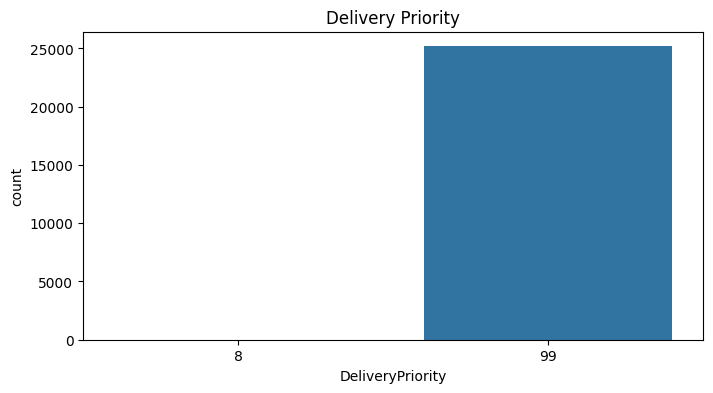

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=orders_clean,
    x="DeliveryPriority"
)

plt.title("Delivery Priority")

plt.show()

### Observation

The chart shows the distribution of delivery priorities across all customer orders.

These priorities may later be incorporated into optimization objectives or business rules.

## Product (SKU) Analysis

This chart identifies the ten most frequently ordered products.

Understanding SKU demand helps improve inventory planning and supports better distribution decisions.

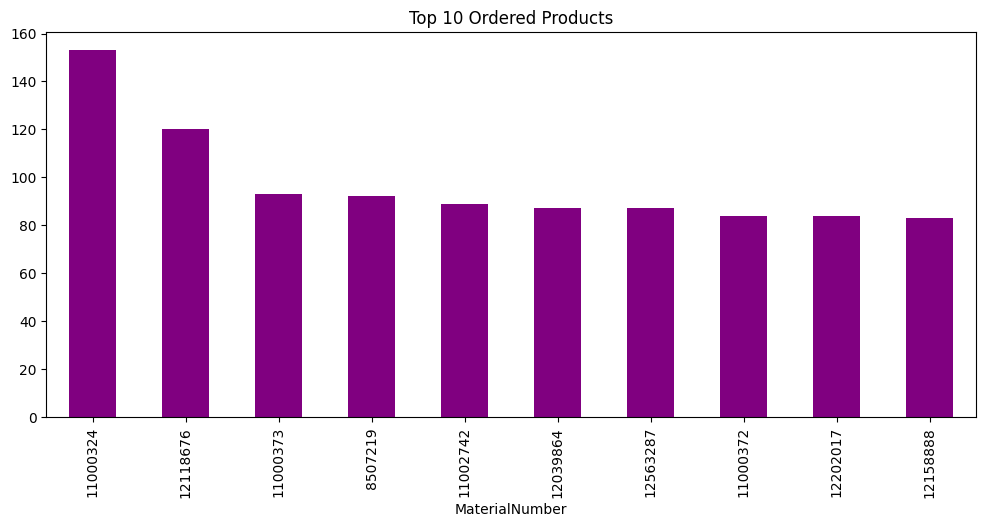

In [26]:
plt.figure(figsize=(12,5))

orders_clean["MaterialNumber"].value_counts().head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Ordered Products")

plt.show()

### Observation

A small number of products account for a large proportion of customer orders.

Frequently requested SKUs require careful inventory allocation across Distribution Centers.

## Correlation Analysis

Correlation analysis measures the relationships among numerical variables.

Strong correlations can reveal factors that influence demand, revenue, and optimization performance.

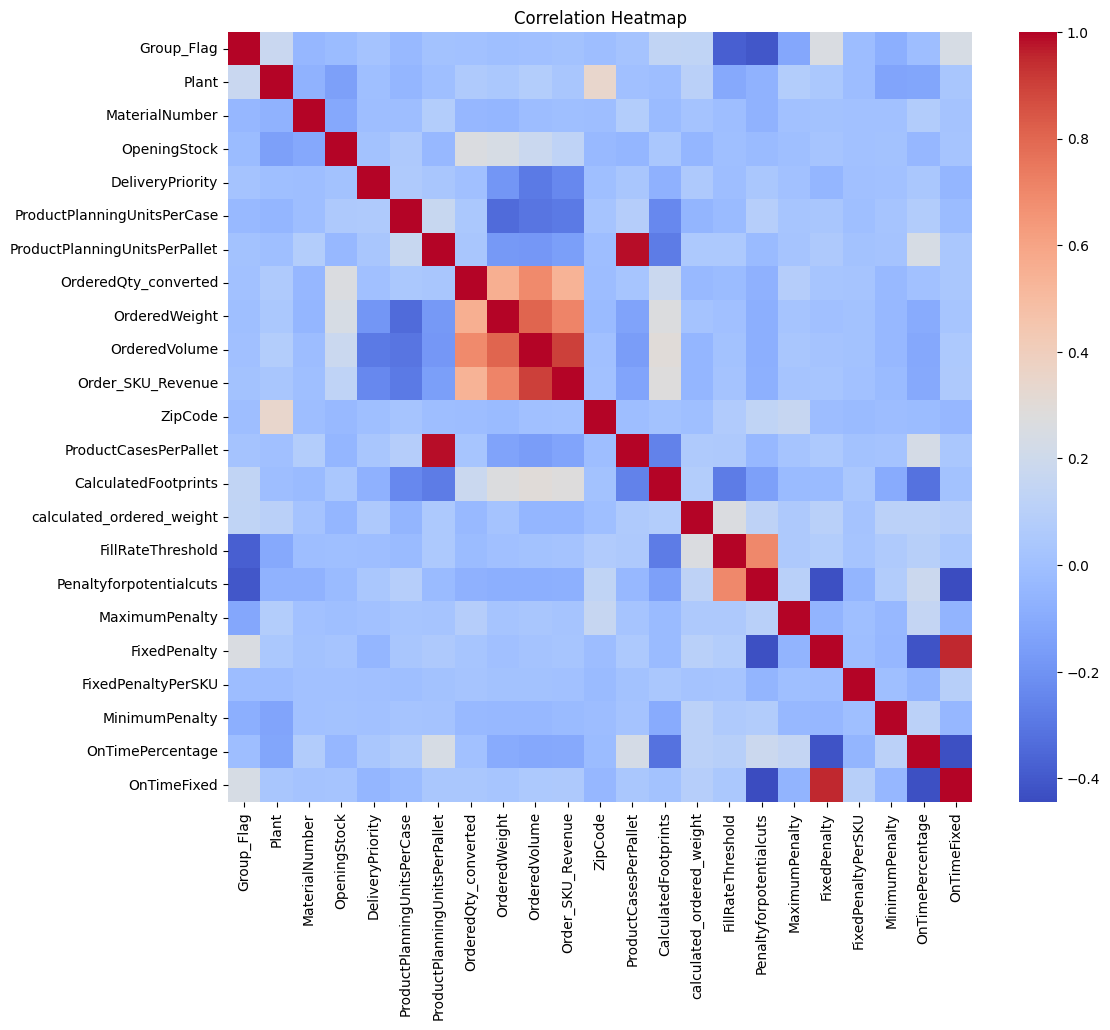

In [27]:
plt.figure(figsize=(12,10))

sns.heatmap(
    orders_clean.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap highlights positive and negative relationships among numerical features.

Understanding these relationships supports feature selection and provides insight into the optimization problem.

In [28]:
orders_clean.to_csv(
    "../data/orders_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# Business Understanding

The Order dataset represents customer demand within the Distributed Order Management (DOM) system.

The optimization model developed in this project will use this information together with inventory, shipping costs, and capacity constraints to determine the best Distribution Center for fulfilling each order.

# Assumptions

The following assumptions are made:

- Every order identifier is unique.
- Shipping costs remain fixed during optimization.
- Inventory values accurately represent available stock.
- Each order can be assigned to at most one Distribution Center.
- Capacity limits are respected by the optimization model.

# Conclusion

In this notebook, the order dataset was successfully loaded and inspected.

The data structure, dimensions, feature names, and descriptive statistics were analyzed to ensure the dataset is suitable for subsequent preprocessing and optimization.

The next notebook will focus on Exploratory Data Analysis (EDA) to gain deeper insights into demand patterns and operational characteristics.